# Student Performance Regression Workflow

## Overview

This notebook builds an end-to-end regression pipeline to predict the final grade of each student from the available student features.

The workflow covers six stages: loading the data, exploring simple relationships, preparing the feature matrix, comparing multiple regression models, tuning the best performer, and saving the final pipeline for reuse.

## How to Read the Output

The key evaluation metrics in this notebook are R2, MAE, and RMSE. R2 shows how much variance the model explains, while MAE and RMSE show the average prediction error in grade points. When comparing models, look for higher R2 and lower error values.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../Data/student_information.csv')

## Initial Data Inspection

The preview below shows the first few rows of the raw student dataset.

This check confirms that the file loaded correctly and gives a quick view of the available columns, sample values, and overall structure before any feature engineering begins.

In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0.0,11.0,11.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9.0,11.0,11.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12.0,13.0,12.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14.0,14.0,14.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11.0,13.0,13.0


## Target and Feature Setup

Here the grade column is separated from the feature matrix so the model can be trained on predictors only.

`X` contains the input variables, while `y` contains the final grade that the regression models will learn to predict.

In [5]:
X = df.drop(columns=['G3'], axis=1)
y = df['G3']

In [6]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Train-Test Split

The dataset is split into training and test sets so the regression models can be evaluated on unseen data.

A random state is used to make the split reproducible, which helps when comparing results across multiple runs.

In [9]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Definitions

Six regression pipelines are created here, each combining the same preprocessing steps with a different regressor.

### Models Being Compared

- **Linear Regression**: A simple baseline model.
- **Decision Tree Regressor**: Can capture non-linear relationships but may overfit.
- **Random Forest Regressor**: An ensemble approach that usually generalizes better than a single tree.
- **Gradient Boosting Regressor**: Builds trees sequentially to reduce prediction error.
- **Support Vector Regressor**: Can work well on smaller, well-prepared datasets.
- **XGBoost Regressor**: A boosted tree model that is often strong on structured tabular data.

Using the same preprocessing pipeline for every model makes the comparison fair.

## Preprocessing Pipeline

This preprocessing block prepares numeric and categorical features in different ways before they are passed into the regression models.

### What Happens Here

- Numeric columns are imputed with the median and then scaled.
- Categorical columns are imputed with the most frequent value and one-hot encoded.
- The `ColumnTransformer` merges both branches into a single matrix for model training.

Using a shared preprocessing pipeline keeps every model on the same footing during comparison.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [11]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

svr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR())
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Evaluation Function

The reusable evaluation function below fits each model, generates predictions on the test set, and prints three regression metrics.

### Metric Interpretation

- **R2**: How much of the variance in the target is explained by the model. Higher is better.
- **MAE**: The average absolute prediction error in grade points. Lower is better.
- **RMSE**: Similar to MAE, but penalizes larger errors more strongly. Lower is better.

These metrics provide complementary views of model quality, so it is useful to inspect all three together rather than relying on a single score.

In [13]:
def evaluate_model(name, pipeline):
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    print(f"--- {name} ---")
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print()

## Baseline Model Comparison

The cells below evaluate all six models using their default settings on the test set.

### What to Look For

- Which model gives the highest R2?
- Which model has the lowest MAE and RMSE?
- Are there models that look good on one metric but weak on another?

The strongest baseline is the best candidate for tuning in the next section.

In [14]:
evaluate_model("Linear Regression", lr_pipeline)
evaluate_model("Decision Tree", dt_pipeline)
evaluate_model("Random Forest", rf_pipeline)
evaluate_model("Gradient Boosting", gb_pipeline)
evaluate_model("Support Vector Regressor", svr_pipeline)
evaluate_model('XGBoost', xgb_pipeline)

--- Linear Regression ---
R2: 0.8385512666651314
MAE: 1.0018015629062806
RMSE: 1.5345545658941417

--- Decision Tree ---
R2: 0.7014857437037176
MAE: 1.1196172248803828
RMSE: 2.0866401188623622

--- Random Forest ---
R2: 0.8678563432926155
MAE: 0.887842105263158
RMSE: 1.388315508194156

--- Gradient Boosting ---
R2: 0.8746911633602183
MAE: 0.917471438383266
RMSE: 1.3519351624077869

--- Support Vector Regressor ---
R2: 0.7490821190184134
MAE: 1.133492420559657
RMSE: 1.9130698194113789

--- XGBoost ---
R2: 0.8375276503115665
MAE: 0.9933253892799884
RMSE: 1.539411566601954



## Hyperparameter Search

The next step is to tune the Gradient Boosting model using grid search.

The parameter grid explores different tree depths, learning rates, regularization choices, and loss functions. Cross-validation is used so the selected configuration is not based on a single split of the data.

In [15]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [0.8, 1.0],
    "model__loss": ["squared_error", "absolute_error"]
}

In [16]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__loss': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

## Tuned Model Results

The cells below show the best grid-search configuration and the test-set performance of the selected model.

Compare these scores with the baseline models to see whether tuning improved R2 and reduced prediction error.

In [17]:
best_model = grid_search.best_estimator_

print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__learning_rate': 0.03, 'model__loss': 'squared_error', 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}
0.8412291977850241


In [18]:
y_pred = best_model.predict(x_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R2: 0.8727215696702163
MAE: 0.892721012849015
RMSE: 1.3625185386362229


In [19]:
print(best_model.score(x_test, y_test))

0.8727215696702163


## Feature Importance Analysis

The feature importance section explains which inputs the tuned tree-based model relies on most when making predictions.

The table and bar plot below help answer a useful question: which student attributes appear to contribute most to the predicted final grade? This does not prove causation, but it does provide a practical ranking of influential features.

In [20]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_model.named_steps[
    "model"
].feature_importances_

In [21]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [22]:
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(15)

,feature,importance
14,num__G2,0.880524
12,num__absences,0.061982
13,num__G1,0.042256
5,num__failures,0.004741
11,num__health,0.000986
17,cat__sex_F,0.000939
0,num__age,0.000875
18,cat__sex_M,0.000858
33,cat__Fjob_services,0.000854
8,num__goout,0.000817


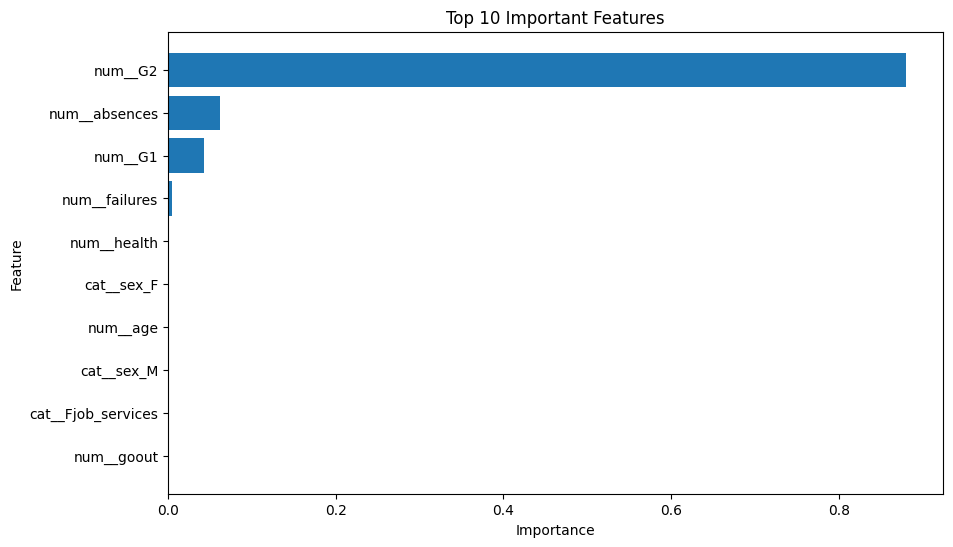

In [23]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.show()

## Saving the Final Pipeline

The trained pipeline is saved with joblib so it can be reused later without retraining.

Saving the full pipeline, rather than just the model alone, ensures that the same preprocessing steps are applied consistently during inference.

In [24]:
import joblib
import os

In [25]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    best_model,
    "models/g3_pipeline.pkl"
)

['models/g3_pipeline.pkl']

## Summary

This notebook shows a complete regression workflow for student performance prediction.

The main takeaways are:
- The raw dataset can be explored with simple summary checks and grouped statistics.
- A shared preprocessing pipeline keeps all models comparable.
- Baseline regression models can be evaluated with R2, MAE, and RMSE.
- Hyperparameter tuning can improve the strongest model.
- The final pipeline can be saved for later use in the backend or another inference workflow.

If you continue working on this project, the next step is usually to compare this regression pipeline with the classification notebook and decide which formulation is more useful for the final application.

In [26]:
import shap

In [27]:
model = best_model.named_steps["model"]

preprocessor = best_model.named_steps[
    "preprocessor"
]

X_processed = preprocessor.transform(x_train)

feature_names = preprocessor.get_feature_names_out()

In [28]:
explainer = shap.Explainer(
    model,
    X_processed
)

shap_values = explainer(X_processed)

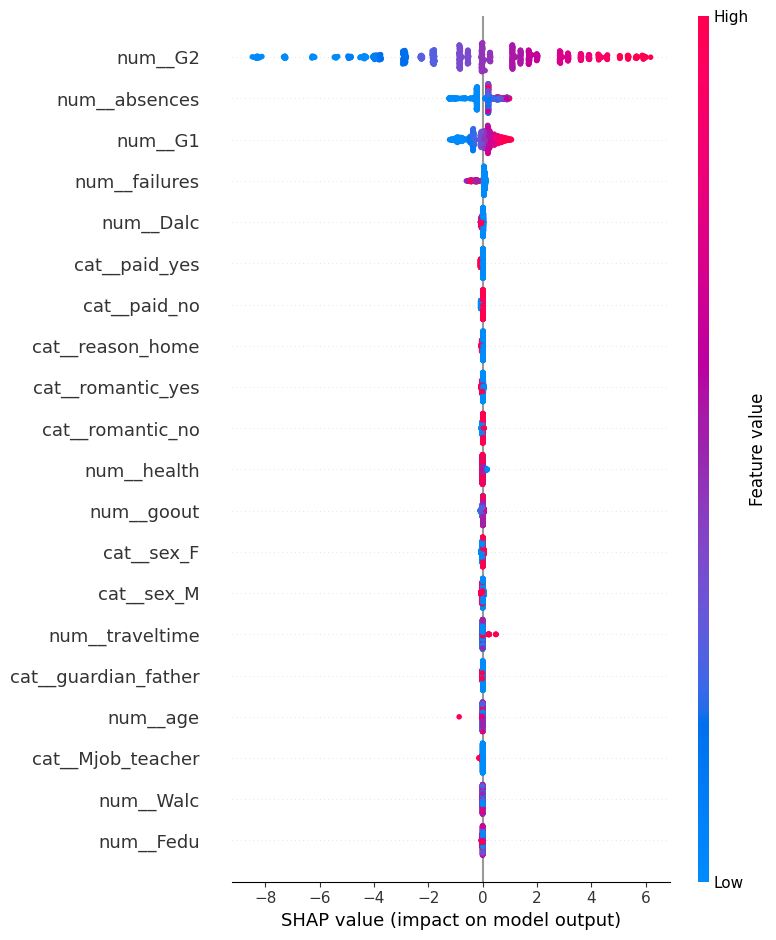

In [29]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names
)

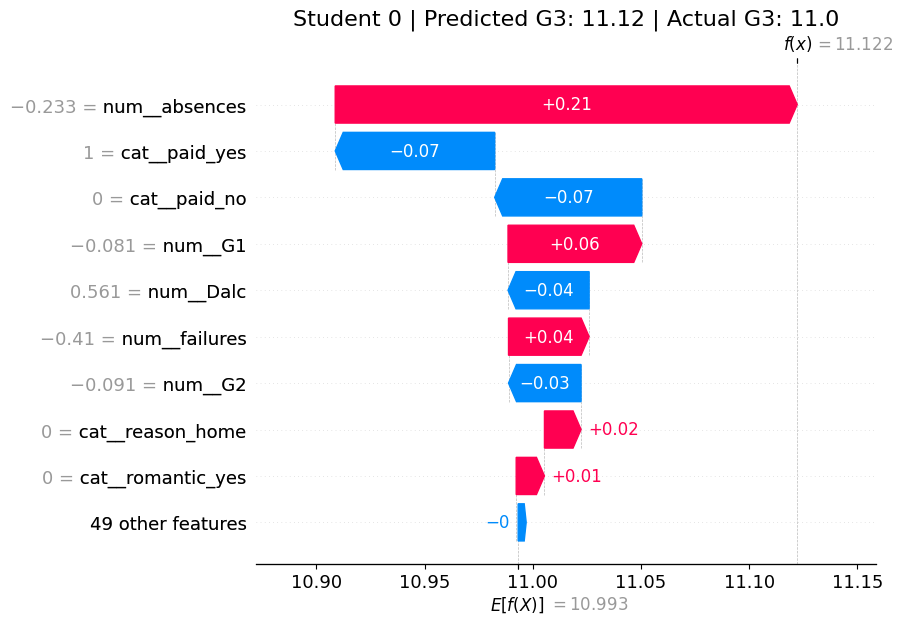

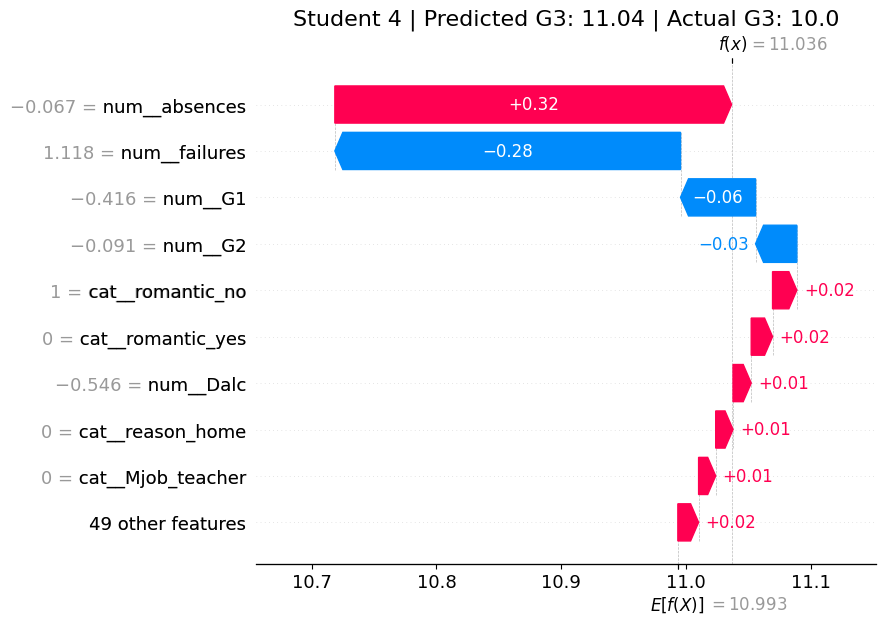

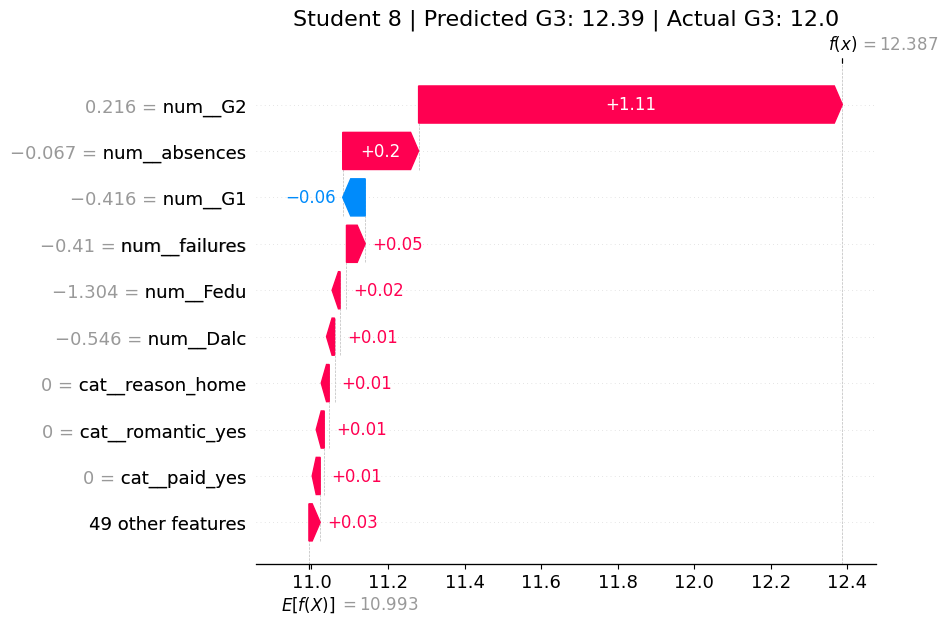

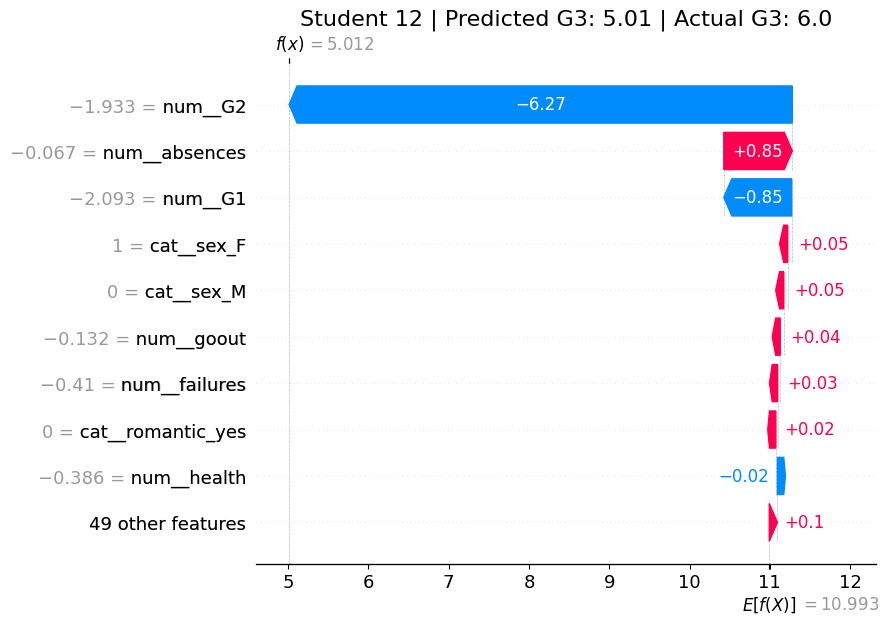

In [41]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

model = best_model.named_steps["model"]

preprocessor = best_model.named_steps[
    "preprocessor"
]

feature_names = preprocessor.get_feature_names_out()

X_processed = preprocessor.transform(
    x_train
)

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

explainer = shap.Explainer(
    model,
    X_processed_df
)

student_indices = [0, 4, 8, 12]

for idx in student_indices:

    student = x_test.iloc[[idx]]

    student_processed = preprocessor.transform(
        student
    )

    student_processed_df = pd.DataFrame(
        student_processed,
        columns=feature_names
    )

    student_shap = explainer(
        student_processed_df
    )

    predicted_value = best_model.predict(
        student
    )[0]

    actual_value = y_test.iloc[idx]

    plt.figure(figsize=(18, 9))

    shap.plots.waterfall(
        student_shap[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Student {idx} | Predicted G3: {predicted_value:.2f} | Actual G3: {actual_value}",
        fontsize=16
    )

    plt.show()